# Desarrollo de ejemplos de elementos tipo truss 2D python & ANSYS
Desarrollaremos el siguiente ejemplo
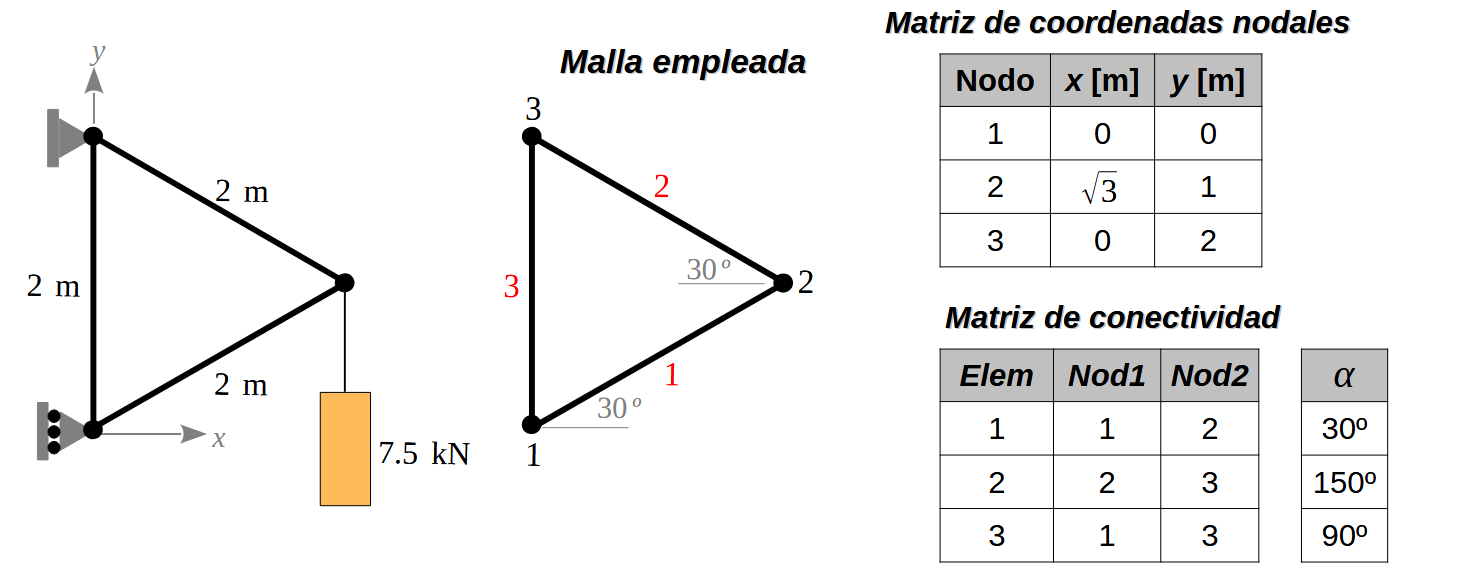
Para su desarrolo debemos aplicar el método de FEM de forma directa. Primero recordemos que los elementos truss en 2D cuentan con dos grados de libertad, el desplazamiento de cada uno de los nodos puede presentarse en 2 dimensiones. Tendremo 2n grados de libertad siendo n el numero de nodos dentro del problema.
Las barras que componen las geometrías de los sistemas seben ser resueltas en un sistema coordenado global NOTA(sus matrices de rigidez elemental), sin embargo, en el problema estos elementos estrán en sistemas coordenados locales NOTA(las matrices de rigidez elementales de la forma 1D están en un sistema coordenado local)
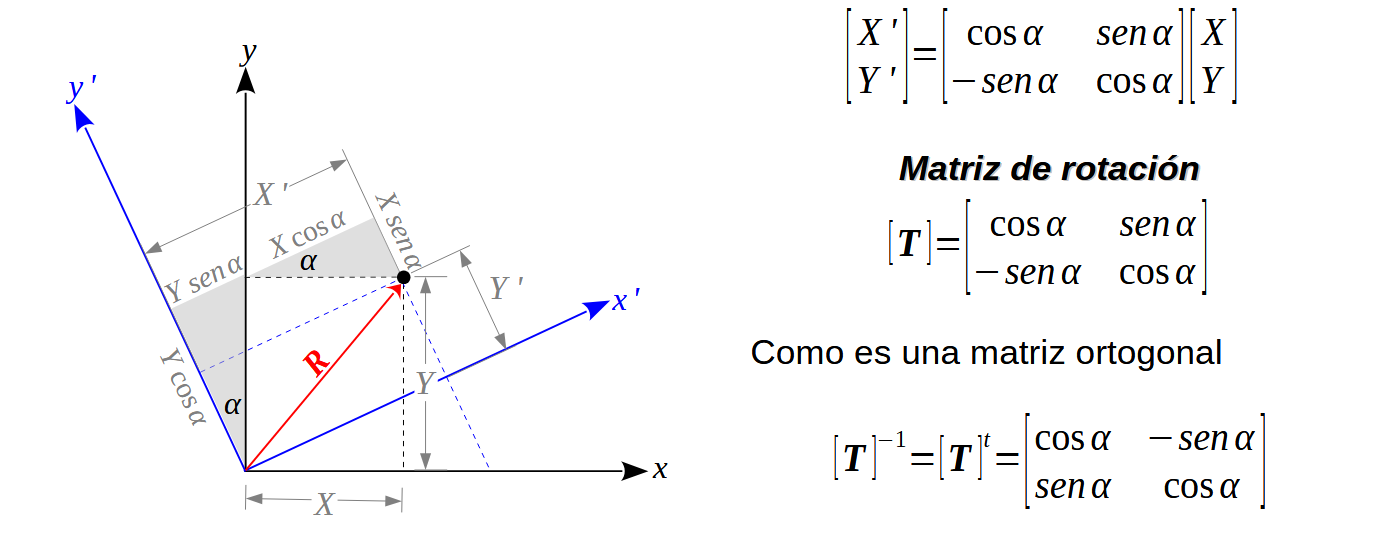
De este modo debemos incluir dentro de la solución una forma en que la matriz de rotación lleve los elementos de un sistema local a un sistema global
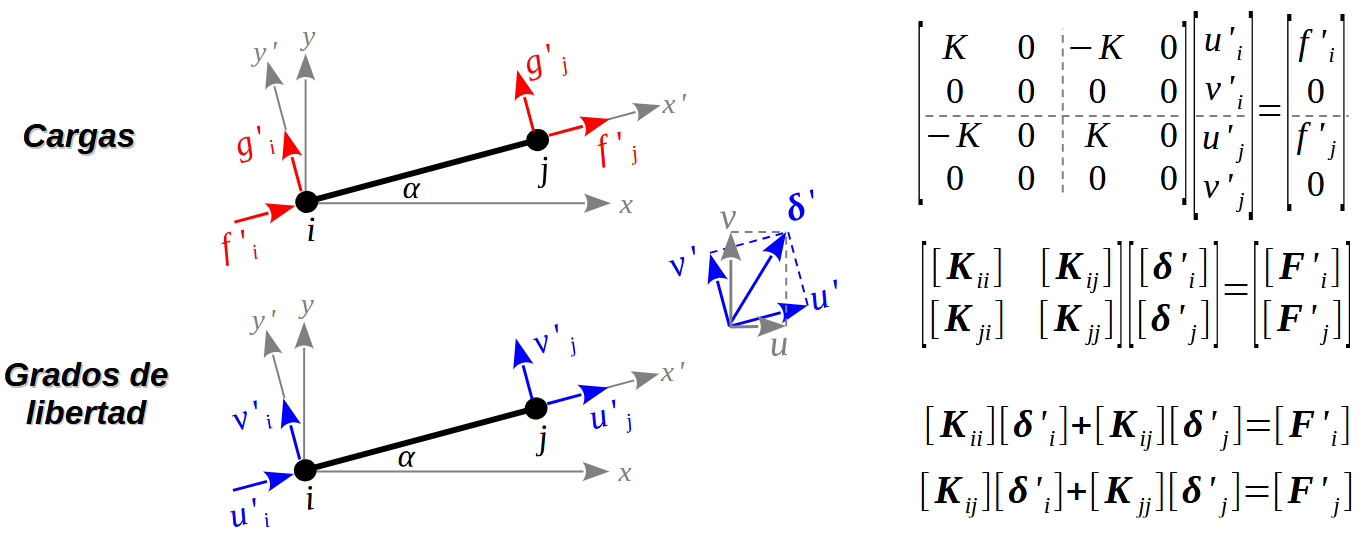
Llevaremos las matrices locales a matrices de rigidez globales
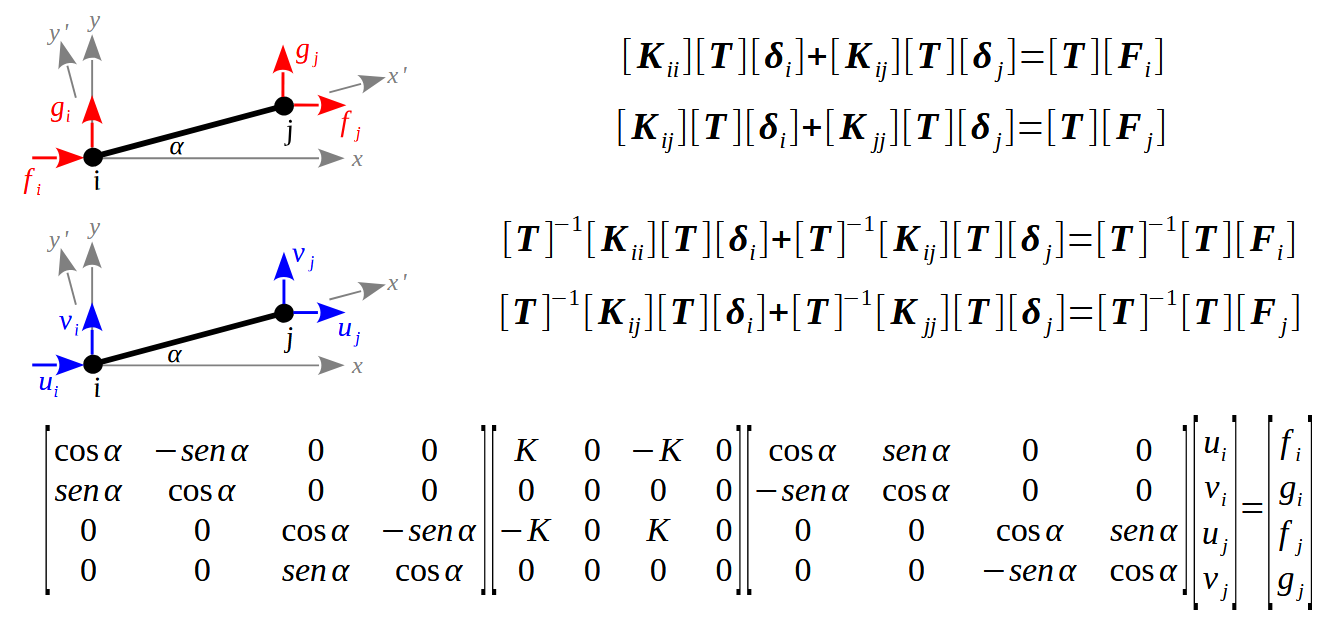

In [1]:
# Importacion de librerias 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# ==============================================================
# ① Estructura original
# ==============================================================
def plot_truss(Mnod, Melem, x, 
               node_color='crimson', 
               elem_color='forestgreen', 
               text_color='royalblue',
               linewidth=1.5, 
               figsize=(6,4)):
    """
    Dibuja la estructura tipo TRUSS (marco original)
    """
    plt.figure(figsize=figsize)
    
    # Dibujar elementos
    for e_idx, row in enumerate(Melem, start=1):
        n1, n2 = int(row[0]) - 1, int(row[1]) - 1
        plt.plot([Mnod[n1, 0], Mnod[n2, 0]],
                 [Mnod[n1, 1], Mnod[n2, 1]],
                 'k-', lw=linewidth)
    
    # Dibujar nodos originales
    Norig = len(x)
    plt.scatter(Mnod[:Norig, 0], Mnod[:Norig, 1],
                c=node_color, label='Nodos originales', zorder=3)
    
    # Numeración de nodos
    for i, (xi, yi) in enumerate(Mnod, start=1):
        plt.text(xi, yi + 0.005, str(i),
                 color=text_color, fontsize=9, ha='center')
    
    # Numeración de elementos
    for ei, row in enumerate(Melem, start=1):
        n1, n2 = int(row[0]) - 1, int(row[1]) - 1
        xm = (Mnod[n1, 0] + Mnod[n2, 0]) / 2
        ym = (Mnod[n1, 1] + Mnod[n2, 1]) / 2
        plt.text(xm, ym, f"e{ei}",
                 color=elem_color, fontsize=8, ha='center')
    
    plt.axis('equal')
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("① Marco original")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==============================================================
# ② Estructura deformada + ③ Esfuerzos axiales
# ==============================================================
def plot_deformed_truss(Mnod, Melem, UG, scale=1.0):
    """
    Dibuja el marco deformado y el mapa de esfuerzos axiales
    """
    Nelem = Melem.shape[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cmap = plt.cm.plasma
    
    # ------------------------
    # ② Marco deformado
    # ------------------------
    ax = axes[0]
    for i in range(Nelem):
        nod1, nod2 = int(Melem[i, 0]) - 1, int(Melem[i, 1]) - 1
        # Coordenadas originales
        x1, y1 = Mnod[nod1]
        x2, y2 = Mnod[nod2]
        # Coordenadas deformadas
        x1d = x1 + scale * UG[2*nod1]
        y1d = y1 + scale * UG[2*nod1 + 1]
        x2d = x2 + scale * UG[2*nod2]
        y2d = y2 + scale * UG[2*nod2 + 1]
        ax.plot([x1, x2], [y1, y2], 'k--', lw=1.0, alpha=0.6)
        ax.plot([x1d, x2d], [y1d, y2d], 'r-', lw=2.0)
    
    ax.set_title("② Marco deformado (escala {:.1f})".format(scale))
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.axis("equal")
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # ------------------------
    # ③ Marco con esfuerzos axiales
    # ------------------------
    N = np.zeros(Nelem)
    for i in range(Nelem):
        nod1, nod2 = int(Melem[i, 0]) - 1, int(Melem[i, 1]) - 1
        ui, vi = UG[2*nod1], UG[2*nod1 + 1]
        uj, vj = UG[2*nod2], UG[2*nod2 + 1]
        x1, y1 = Mnod[nod1]
        x2, y2 = Mnod[nod2]
        L = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        Q = np.arctan2((y2 - y1), (x2 - x1))
        c, s = np.cos(Q), np.sin(Q)
        Dup = float(uj - ui)
        Dvp = float(vj - vi)
        delta = c*Dup + s*Dvp
        E, A = float(Melem[i, 2]), float(Melem[i, 3])
        N[i] = delta * E * A / L   # ← Warning corregido
    
    ax2 = axes[1]
    norm = plt.Normalize(vmin=np.min(N), vmax=np.max(N))
    for i in range(Nelem):
        nod1, nod2 = int(Melem[i, 0]) - 1, int(Melem[i, 1]) - 1
        x1 = Mnod[nod1, 0] + scale * UG[2*nod1]
        y1 = Mnod[nod1, 1] + scale * UG[2*nod1 + 1]
        x2 = Mnod[nod2, 0] + scale * UG[2*nod2]
        y2 = Mnod[nod2, 1] + scale * UG[2*nod2 + 1]
        color = cmap(norm(N[i]))
        ax2.plot([x1, x2], [y1, y2], color=color, linewidth=3.0)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax2)
    cbar.set_label("Esfuerzo axial [Pa]", fontsize=11)
    cbar.ax.tick_params(labelsize=10)
    
    ax2.set_title("③ Esfuerzos axiales")
    ax2.set_xlabel("x [m]")
    ax2.set_ylabel("y [m]")
    ax2.axis("equal")
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return N

# Funciones que se requiere
 1. Que funciones deben incluirse en desarrollo del problema
 2. Como podemos hacer la transfomación del sistema local(natural) al sistema global del caso
 3. Como afecta la inclusion de nuevos grados de libertad


In [3]:
def mat_rot(alfa):
    "alfa en el angulo de inclinacion de cada uno de los elementos"
    cos_a = np.cos(alfa)
    sin_a = np.sin(alfa)
    # Definimos la matriz de rotacion T
    T = np.zeros((4,4),dtype=np.float64)
    T[0,0] = cos_a
    T[0,1] = -sin_a
    T[1,0] = sin_a
    T[1,1] = cos_a
    T[2,2] = cos_a
    T[2,3] = -sin_a
    T[3,2] = sin_a
    T[3,3] = cos_a
    return T
def mat_Ke(Mnod,Melem,e):
    "Matriz de rigidez elemental"
    #Buscamos en la matriz de Mnod las coordenadas
    nod1 = np.int64(Melem[e,0])-1
    nod2 = np.int64(Melem[e,1])-1
    E = Melem[e, 2]
    A = Melem[e, 3]
    #Buscamos las coordenadas de cada nodo en Mnod
    # print(Mnod)
    # print(nod1)
    # print(nod2)
    x1,y1 = Mnod[nod1,0],Mnod[nod1,1]
    x2,y2 = Mnod[nod2,0],Mnod[nod2,1]
    #Con las coordenadas calculamos la longitud y angulo del elemento
    L = np.sqrt((x2-x1)**2+(y2-y1)**2) # Formula de distancia entre dos puntos
    alfa = np.arctan2((y2-y1),(x2-x1)) # Calculamos el angulo de cada elemento
    # LLamamos la matriz de rotacion
    T = mat_rot(alfa)
    # Creamos la matriz elemental
    Ke = np.array([[(E*A)/L, 0.0, -(E*A)/L, 0.0],
                  [0.0, 0.0, 0.0, 0.0],
                  [-(E*A)/L,0.0,(E*A)/L,0.0],
                  [0.0, 0.0, 0.0, 0.0]],dtype=np.float64)
    Ke = np.linalg.matmul(np.linalg.inv(T),Ke)
    Ke = np.linalg.matmul(Ke,T)
    return Ke
def mat_KG(Melem,Mnod, KG):
    Nelem = Melem.shape[0]
    for e in range(Nelem):
        #Definimos los grados de libertad del sistema que vamos a resolver
        #Para cada nodo se asocian dos grados de libertad
        print(e)
        nod1 = np.int64(Melem[e,0])-1
        nod2 = np.int64(Melem[e,1])-1
        dofs = np.array([2*nod1,
                        2*nod1+1,
                        2*nod2,
                        2*nod2+1],dtype=np.int64)
        # print(nod1)
        # print(nod2)
        # print(Melem.shape)
        Ee = np.float64(Melem[e, 2])
        Ae = np.float64(Melem[e, 3])
        Ke = mat_Ke(Mnod,Melem,e)
        # Ensamblaje global
        for i in range(len(dofs)):
            for j in range(len(dofs)):
                KG[dofs[i], dofs[j]] += Ke[i, j]
    return KG
def vec_FG(Nnod, Load):
    Nnod = Mnod.shape[0]
    FG = np.zeros((2*Nnod, 1))
    for i in range(Nnod):
        for j in range(2):
            if not np.isnan(Load[i, j]):
                FG[2*i + j, 0] += Load[i, j]
    return FG
def penalizacion(Nnod, Disp, kappa):
    Mpenaliz = np.zeros((2*Nnod, 2*Nnod))
    Vpenaliz = np.zeros((2*Nnod, 1))
    for i in range(Nnod):
        for j in range(2):
            if not np.isnan(Disp[i, j]):
                idx = 2*i + j
                Mpenaliz[idx, idx] += kappa
                Vpenaliz[idx, 0] += kappa * Disp[i, j]

    return Mpenaliz, Vpenaliz
    
    

# Solucionar el sistema
    1.Estableremos los nodos del sistemas para crear las matirces de nodos y elementos. 
    2.Se aplican las condiciones de contorno en el vector de cargas y de desplzamientos o restricciones de movimiento3. 
    3.Se aplica el metodo de penalización y se observa la solucion

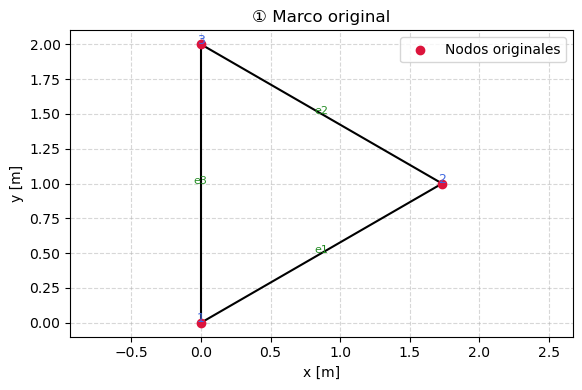

0
1
2
[[ 6.49519053e-12]
 [-4.28571504e-05]
 [ 1.23717915e-05]
 [-1.92857162e-04]
 [-6.49519053e-12]
 [-7.50000000e-12]]


C:\Users\david\AppData\Local\Temp\ipykernel_9516\1530789852.py:97: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Dup = float(uj - ui)
C:\Users\david\AppData\Local\Temp\ipykernel_9516\1530789852.py:98: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Dvp = float(vj - vi)


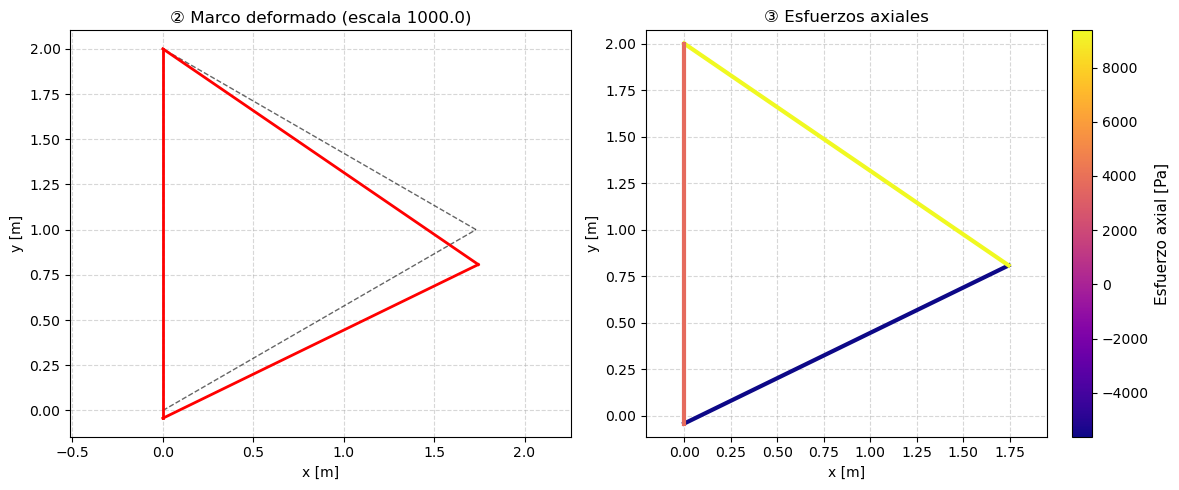

array([-5625.00098438,  9375.00098438,  3750.        ])

In [14]:
x = np.array([0,np.sqrt(3),0],dtype=np.float64)
y = np.array([0,1,2],dtype=np.float64)
Mnod = np.stack((x,y),axis=-1)
Melem = np.array([[1,2,70e9,25*(1/100)**2],
                  [2,3,70e9,25*(1/100)**2],
                  [1,3,70e9,25*(1/100)**2]],dtype=np.float64)
Load = np.array([[np.nan,np.nan],
                 [np.nan,-7.5e3],
                 [np.nan,np.nan]],dtype=np.float64)
Disp = np.array([[0.0,np.nan],
                 [np.nan,np.nan],
                 [0.0,0.0]],dtype=np.float64)

plot_truss(Mnod, Melem, x)
KG = np.zeros((2*Mnod.shape[0], 2*Mnod.shape[0]),dtype=np.float64)
FG = np.zeros((2*Mnod.shape[0], 1),dtype=np.float64)
KG = mat_KG(Melem,Mnod,KG)
FG = vec_FG(Mnod.shape[0],Load)
kappa = 1e15
Mpenaliz,Vpenaliz = penalizacion(Mnod.shape[0], Disp, kappa)
UG = np.linalg.solve(KG+Mpenaliz,FG+Vpenaliz)
print(UG)
plot_deformed_truss(Mnod, Melem, UG, scale=1e3)



# Sección de ANSYS
Para resolver el caso en ANSYS partiremso de la creación la seleccion del material
Se escoge un material acero con modulo de Young de 210GPa y relación de Poisson de 0.3
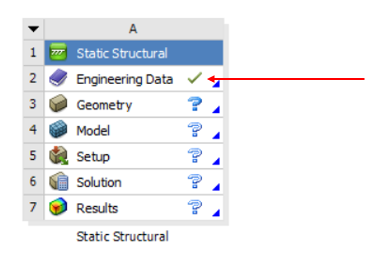
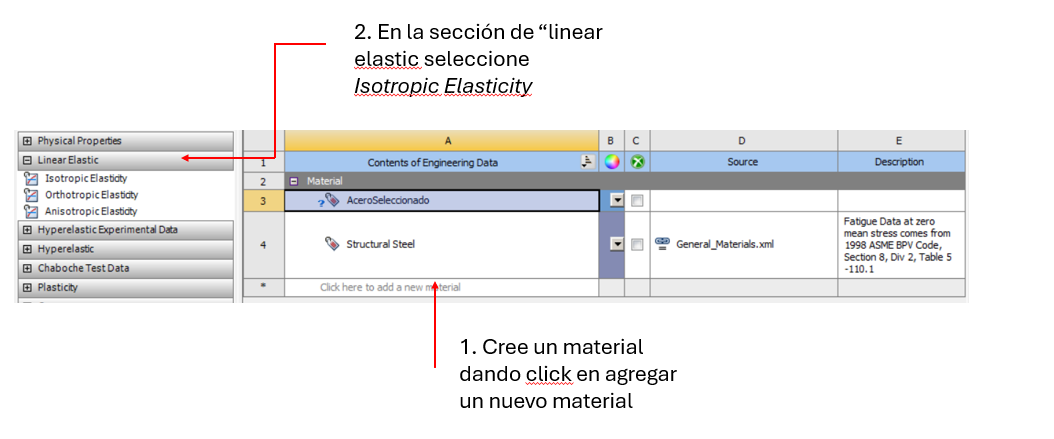
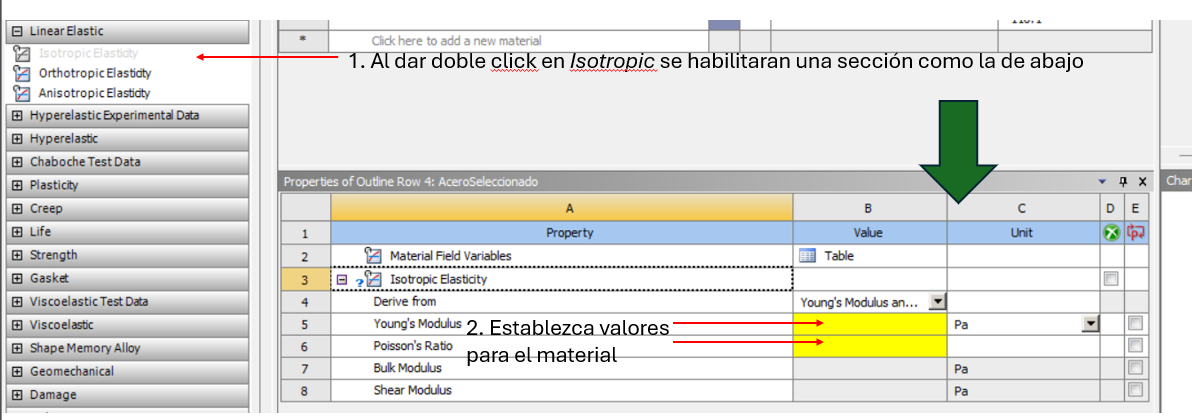
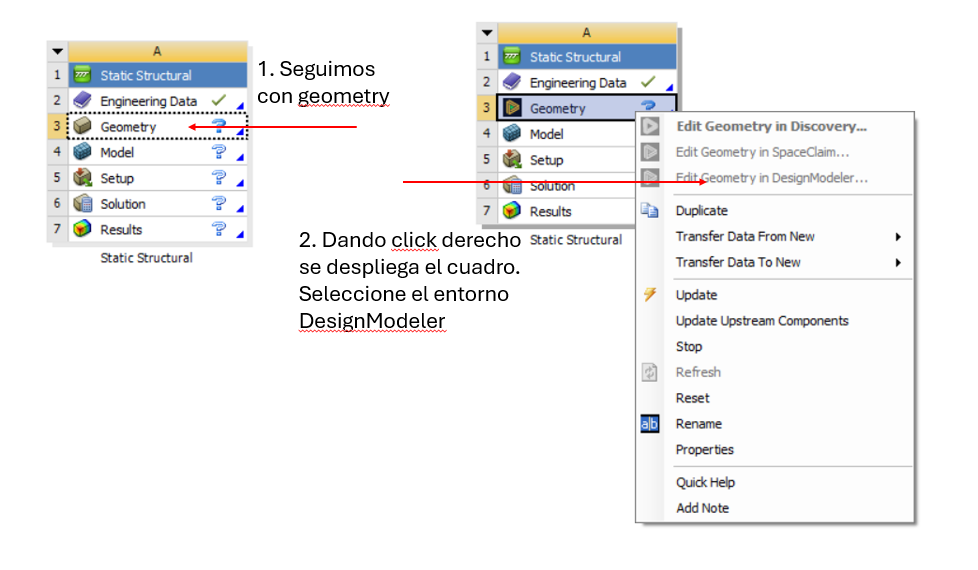
    
1. Debe ver una panatalla como la siguiente
        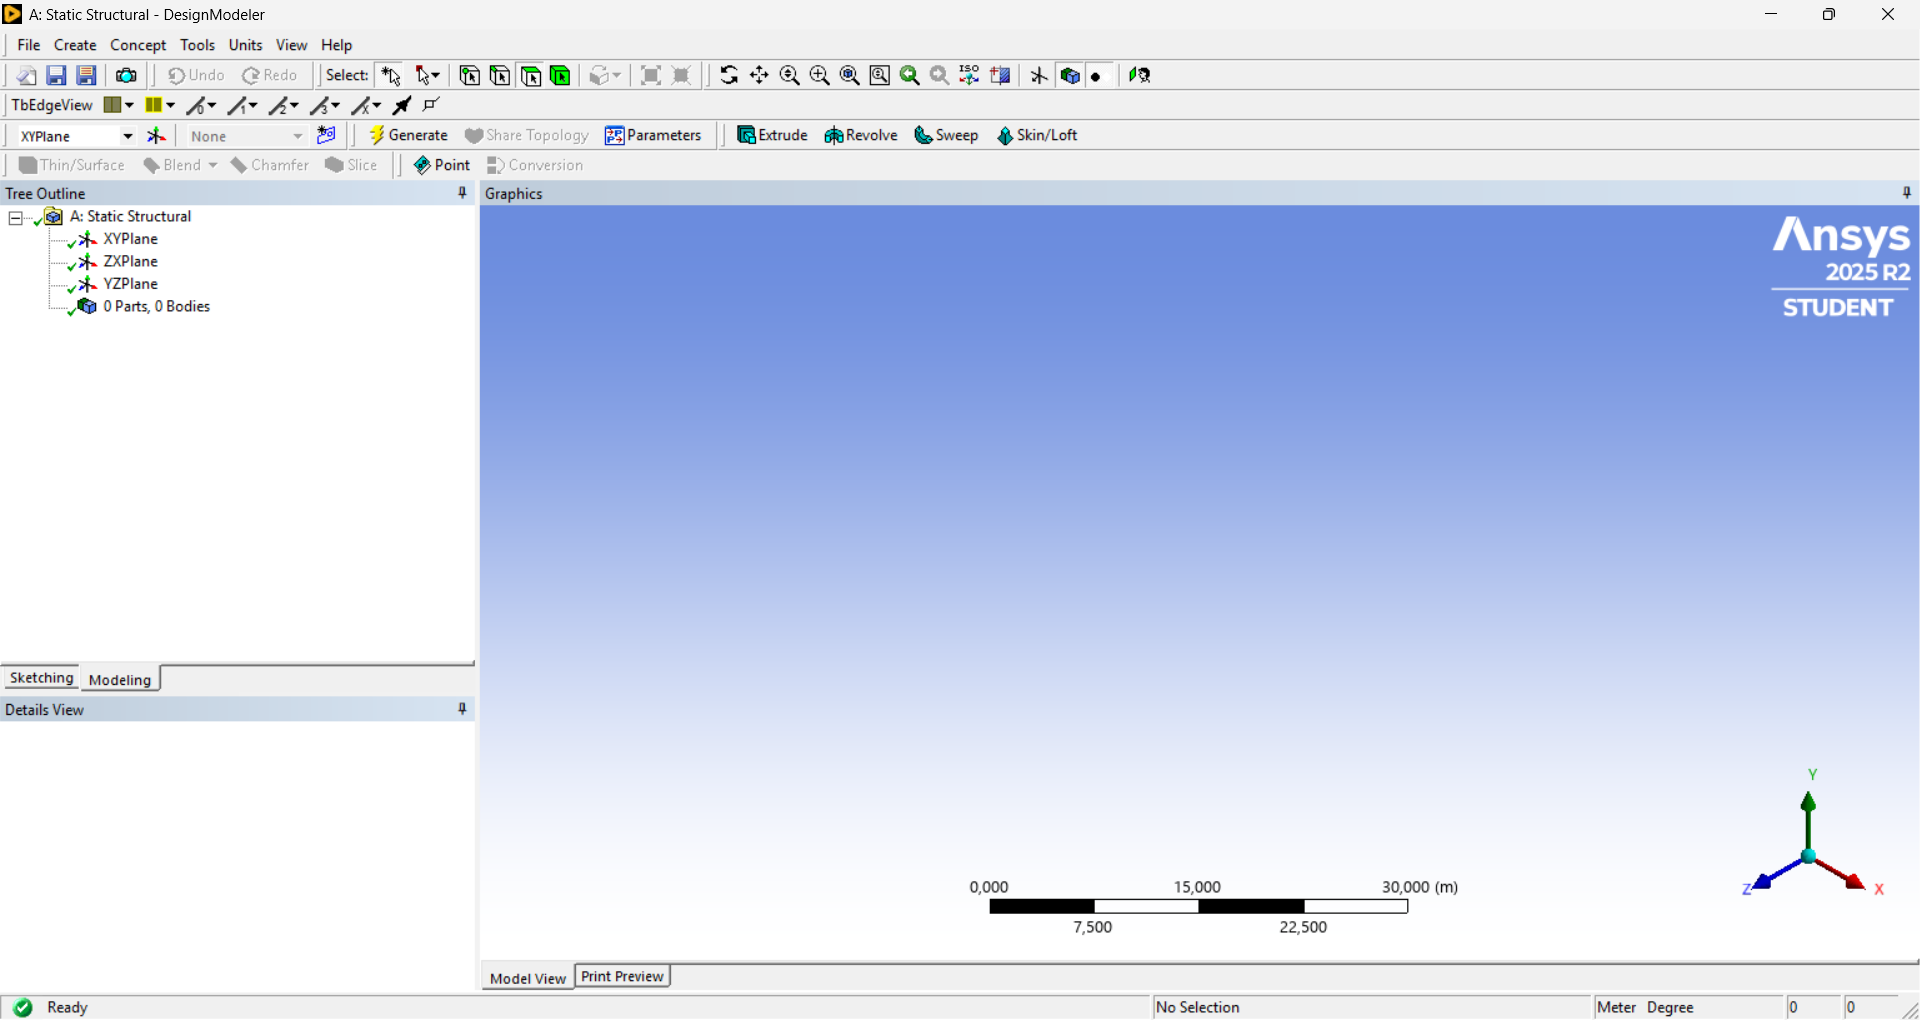
        
2. Dentro de ese entorno cree la estructura del ejemplo siguiendo la reunion en meet
3. Establezca el modelo adecuado dentro de model
        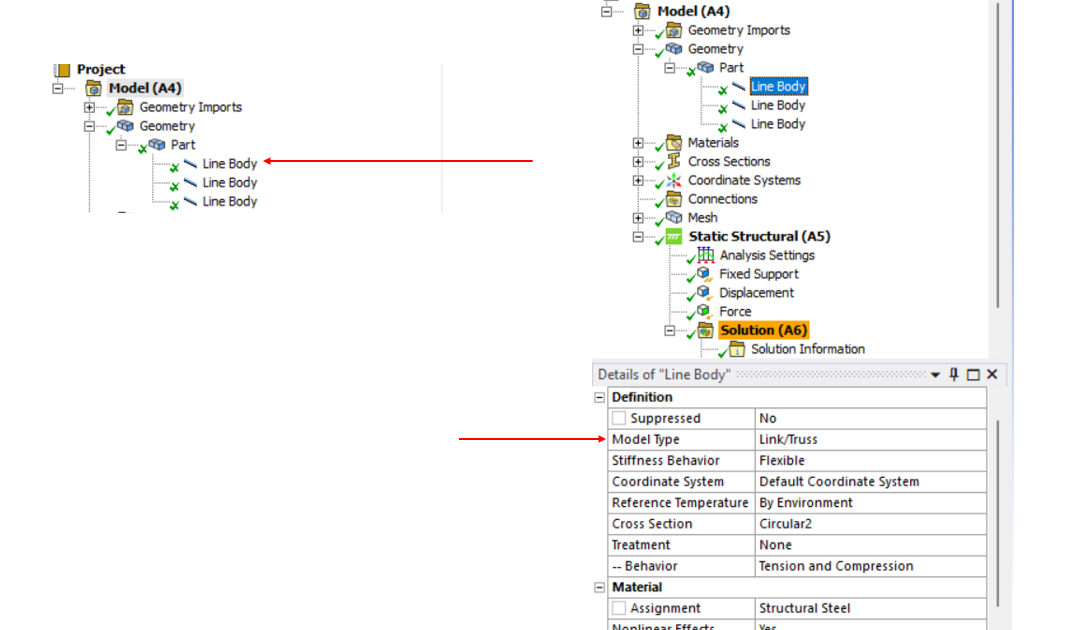

4. Establezca las condiciones de contorno dentro de model
    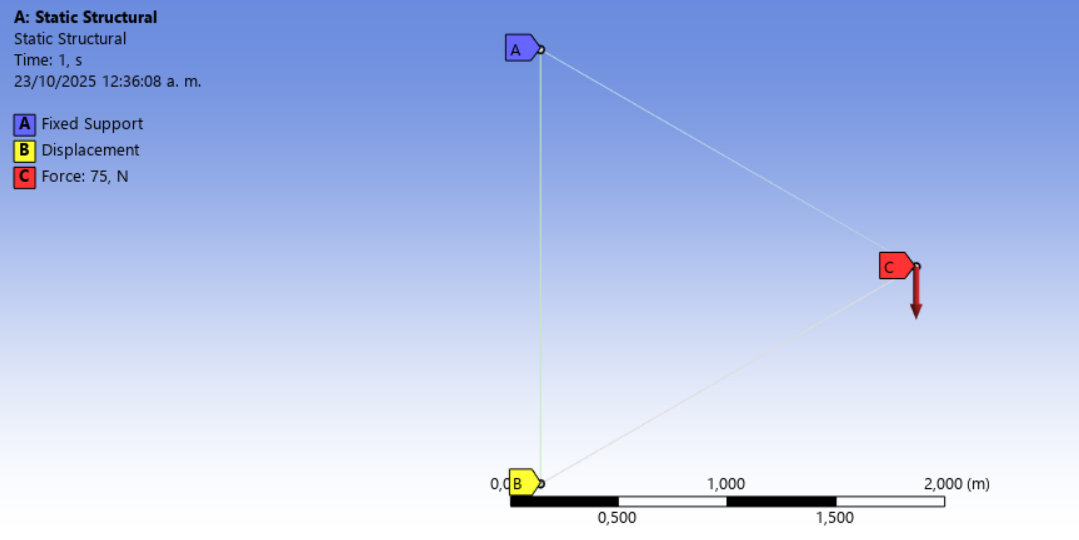
   
6. Revise los resultados obtenidos y comparelos con los obtenidos mediante codigo
    